# ML-Klassifikations-Benchmark (Iris-Datensatz)

Dieses Notebook führt durch das gesamte Projekt und demonstriert den **Benchmark von 8 verschiedenen Machine-Learning-Klassifikationsmodellen** anhand des Iris-Datensatzes.

## Verwendete Design Patterns (GoF)

| Pattern | Zweck | Implementierung |
|---------|-------|-----------------|
| **Strategy** | Austauschbare Algorithmen hinter einem gemeinsamen Interface | `ClassifierStrategy` (ABC) + 8 konkrete Strategien |
| **Factory** | Zentrale Erzeugung von Strategie-Objekten über String-Keys | `ClassifierFactory` |
| **Adapter** | Beliebiges sklearn-Modell an unser Interface anpassen | `SklearnAdapter` |
| **Decorator** | Logging von Methodenaufrufen ohne Code-Änderung | `@log_method` |

## Projektstruktur

```
main.py                  → Einstiegspunkt (Client)
  └─ Trainer             → Datenvorbereitung & Benchmark-Orchestrierung
      ├─ ClassifierFactory   → Erzeugt Modelle über String-Key
      │   └─ ClassifierStrategy (ABC) → 8 konkrete Strategien
      ├─ SklearnAdapter      → Adapter für beliebige sklearn-Modelle
      └─ Metric              → Error Rate & Confusion Matrix
```

---
## 1. Setup & Imports

Zuerst fügen wir das Projektverzeichnis zum Python-Pfad hinzu, damit die Module aus `src/` importiert werden können. Danach importieren wir die benötigten Klassen.

In [1]:
import sys
import os

# Projektverzeichnis zum Pfad hinzufügen (eine Ebene über notebooks/)
projekt_pfad = os.path.abspath(os.path.join(os.getcwd(), '..'))
if projekt_pfad not in sys.path:
    sys.path.insert(0, projekt_pfad)

print(f"Projekt-Pfad: {projekt_pfad}")

Projekt-Pfad: C:\Code\AUGSBURG_10237747_Python_Simon


In [2]:
import logging
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.trainer import Trainer
from src.factory import ClassifierFactory
from src.adapter import SklearnAdapter
from src.interfaces import ClassifierStrategy
from src.metrics import Metric

# Logging konfigurieren
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")

# Matplotlib-Grafiken inline anzeigen
%matplotlib inline

print("Alle Imports erfolgreich!")

Alle Imports erfolgreich!


---
## 2. Strategy Pattern – Das Interface

Das **Strategy Pattern** definiert eine Familie von Algorithmen, kapselt sie und macht sie austauschbar.

Die abstrakte Basisklasse `ClassifierStrategy` bildet das gemeinsame Interface für alle Klassifikatoren:

```python
class ClassifierStrategy(ABC):
    @abstractmethod
    def fit(self, X, y):   # Trainiert das Modell
        pass

    @abstractmethod
    def predict(self, X):  # Liefert Vorhersagen
        pass
```

Jede konkrete Strategie (z.B. `DecisionTreeStrategy`, `RandomForestStrategy`, ...) implementiert dieses Interface mit einem spezifischen sklearn-Modell.

### Decorator Pattern – `@log_method`

Zusätzlich nutzt das Projekt den **Decorator `@log_method`**, um `fit()` und `predict()` Aufrufe automatisch zu loggen – ganz ohne den eigentlichen Code zu verändern.

In [3]:
# Schauen wir uns die verfügbaren konkreten Strategien an:
from src.strategies import (
    DecisionTreeStrategy,
    RandomForestStrategy,
    LDAStrategy,
    SVCRbfStrategy,
    SVCLinearStrategy,
    SVCPoly3Strategy,
    LinearSVCStrategy,
    XGBoostStrategy
)

# Alle Strategien erben von ClassifierStrategy (ABC)
strategien = [
    DecisionTreeStrategy,
    RandomForestStrategy,
    LDAStrategy,
    SVCRbfStrategy,
    SVCLinearStrategy,
    SVCPoly3Strategy,
    LinearSVCStrategy,
    XGBoostStrategy
]

print("Konkrete Strategien und ihre Vererbung:")
print("-" * 50)
for s in strategien:
    print(f"  {s.__name__:<25} erbt von → {s.__bases__[0].__name__}")

Konkrete Strategien und ihre Vererbung:
--------------------------------------------------
  DecisionTreeStrategy      erbt von → ClassifierStrategy
  RandomForestStrategy      erbt von → ClassifierStrategy
  LDAStrategy               erbt von → ClassifierStrategy
  SVCRbfStrategy            erbt von → ClassifierStrategy
  SVCLinearStrategy         erbt von → ClassifierStrategy
  SVCPoly3Strategy          erbt von → ClassifierStrategy
  LinearSVCStrategy         erbt von → ClassifierStrategy
  XGBoostStrategy           erbt von → ClassifierStrategy


---
## 3. Factory Pattern – Strategie-Erzeugung

Die `ClassifierFactory` übernimmt die Erzeugung der Strategie-Objekte anhand eines **String-Keys**. Dadurch muss der Client (hier: `main.py` bzw. dieses Notebook) keine konkreten Klassen kennen.

```python
class ClassifierFactory:
    _strategies = {
        "tree":       DecisionTreeStrategy,
        "rf":         RandomForestStrategy,
        "lda":        LDAStrategy,
        ...
    }

    @staticmethod
    def make_classifier(name, **kwargs):
        return ClassifierFactory._strategies[name](**kwargs)
```

In [4]:
# Demonstration: Factory erzeugt Strategien über String-Keys
print("Verfügbare Factory-Keys:")
print("-" * 40)
for key, cls in ClassifierFactory._strategies.items():
    print(f"  '{key}'  →  {cls.__name__}")

# Beispiel: Strategie erzeugen
print("\nBeispiel-Erzeugung:")
beispiel = ClassifierFactory.make_classifier("tree", random_state=123)
print(f"  ClassifierFactory.make_classifier('tree') → {type(beispiel).__name__}")
print(f"  Ist ClassifierStrategy? {isinstance(beispiel, ClassifierStrategy)}")

Verfügbare Factory-Keys:
----------------------------------------
  'tree'  →  DecisionTreeStrategy
  'rf'  →  RandomForestStrategy
  'lda'  →  LDAStrategy
  'svm_rbf'  →  SVCRbfStrategy
  'svm_linear'  →  SVCLinearStrategy
  'svm_poly3'  →  SVCPoly3Strategy
  'linear_svc'  →  LinearSVCStrategy
  'xgboost'  →  XGBoostStrategy

Beispiel-Erzeugung:
  ClassifierFactory.make_classifier('tree') → DecisionTreeStrategy
  Ist ClassifierStrategy? True


---
## 4. Der Trainer – Kontext des Strategy Patterns

Der `Trainer` ist der **Kontext** im Strategy Pattern. Er kennt nur das `ClassifierStrategy`-Interface, nicht die konkreten Implementierungen.

Seine Aufgaben:
1. **Daten laden** – Iris-Datensatz via Seaborn
2. **Split** – 15 Test / 135 Train (permutiert mit festem Seed)
3. **Training & Vorhersage** – über das Strategy-Interface
4. **Auswertung** – Error Rate berechnen und Confusion Matrix plotten

In [5]:
# Trainer (Kontext) erstellen und Daten vorbereiten
trainer = Trainer()
trainer.prepare_data()

print(f"Trainings-Datensatz:  {len(trainer.train_data)} Samples")
print(f"Test-Datensatz:       {len(trainer.test_data)} Samples")
print(f"Features:             {trainer.features}")
print(f"Target:               {trainer.target}")
print(f"\nKlassenverteilung (Train):")
print(trainer.train_data[trainer.target].value_counts().to_string())

Trainings-Datensatz:  135 Samples
Test-Datensatz:       15 Samples
Features:             ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target:               species

Klassenverteilung (Train):
species
setosa        46
versicolor    45
virginica     44


### Blick auf die Daten

Der Iris-Datensatz enthält 150 Blumen-Samples mit 4 Merkmalen (Sepal/Petal Länge & Breite) und 3 Klassen (setosa, versicolor, virginica).

In [6]:
# Erste Zeilen des Trainingsdatensatzes
trainer.train_data.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
104,6.5,3.0,5.8,2.2,virginica
36,5.5,3.5,1.3,0.2,setosa
13,4.3,3.0,1.1,0.1,setosa
63,6.1,2.9,4.7,1.4,versicolor
45,4.8,3.0,1.4,0.3,setosa
28,5.2,3.4,1.4,0.2,setosa
133,6.3,2.8,5.1,1.5,virginica
24,4.8,3.4,1.9,0.2,setosa
127,6.1,3.0,4.9,1.8,virginica
46,5.1,3.8,1.6,0.2,setosa


---
## 5. Benchmark – Alle Strategien durchlaufen

Jetzt führen wir den eigentlichen Benchmark durch. Für jede der **8 Strategien**:
1. Die Factory erzeugt das Strategie-Objekt über den String-Key
2. Der Trainer führt Training, Vorhersage und Auswertung durch
3. Eine Confusion-Matrix-Heatmap wird inline angezeigt

Dies entspricht dem Ablauf in `main.py`.

In [7]:
# Liste der 8 Strategie-Keys (identisch zu main.py)
strategy_names = [
    "tree",
    "rf",
    "lda",
    "svm_rbf",
    "svm_linear",
    "svm_poly3",
    "linear_svc",
    "xgboost"
]

print("=" * 55)
print("       STARTE ML-KLASSIFIKATIONS-BENCHMARK")
print("=" * 55)

# Client wählt jede Strategie über die Factory
# und injiziert sie in den Kontext (Trainer)
for name in strategy_names:
    print(f"\n{'─' * 55}")
    print(f"  Modell: {name}")
    print(f"{'─' * 55}")

    # Factory erzeugt die Strategie (Factory Pattern)
    strategy = ClassifierFactory.make_classifier(name, random_state=123)

    # Trainer führt den Benchmark durch (Strategy Pattern)
    trainer.run_single(strategy, name, plot=True)
    plt.show()  # Inline-Anzeige der Heatmap

[INFO] DecisionTreeStrategy.fit() – 135 Samples
[INFO] DecisionTreeStrategy.predict() – 15 Samples
[INFO] RandomForestStrategy.fit() – 135 Samples


       STARTE ML-KLASSIFIKATIONS-BENCHMARK

───────────────────────────────────────────────────────
  Modell: tree
───────────────────────────────────────────────────────
Grafik gespeichert: results/heatmap_tree.png
tree abgeschlossen. Error Rate: 0.0667

───────────────────────────────────────────────────────
  Modell: rf
───────────────────────────────────────────────────────


[INFO] RandomForestStrategy.predict() – 15 Samples
[INFO] LDAStrategy.fit() – 135 Samples
[INFO] LDAStrategy.predict() – 15 Samples


Grafik gespeichert: results/heatmap_rf.png
rf abgeschlossen. Error Rate: 0.0000

───────────────────────────────────────────────────────
  Modell: lda
───────────────────────────────────────────────────────


[INFO] SVCRbfStrategy.fit() – 135 Samples
[INFO] SVCRbfStrategy.predict() – 15 Samples
[INFO] SVCLinearStrategy.fit() – 135 Samples
[INFO] SVCLinearStrategy.predict() – 15 Samples


Grafik gespeichert: results/heatmap_lda.png
lda abgeschlossen. Error Rate: 0.0000

───────────────────────────────────────────────────────
  Modell: svm_rbf
───────────────────────────────────────────────────────
Grafik gespeichert: results/heatmap_svm_rbf.png
svm_rbf abgeschlossen. Error Rate: 0.0667

───────────────────────────────────────────────────────
  Modell: svm_linear
───────────────────────────────────────────────────────


[INFO] SVCPoly3Strategy.fit() – 135 Samples
[INFO] SVCPoly3Strategy.predict() – 15 Samples
[INFO] LinearSVCStrategy.fit() – 135 Samples
[INFO] LinearSVCStrategy.predict() – 15 Samples


Grafik gespeichert: results/heatmap_svm_linear.png
svm_linear abgeschlossen. Error Rate: 0.0667

───────────────────────────────────────────────────────
  Modell: svm_poly3
───────────────────────────────────────────────────────
Grafik gespeichert: results/heatmap_svm_poly3.png
svm_poly3 abgeschlossen. Error Rate: 0.0667

───────────────────────────────────────────────────────
  Modell: linear_svc
───────────────────────────────────────────────────────


[INFO] XGBoostStrategy.fit() – 135 Samples
[INFO] XGBoostStrategy.predict() – 15 Samples


Grafik gespeichert: results/heatmap_linear_svc.png
linear_svc abgeschlossen. Error Rate: 0.0000

───────────────────────────────────────────────────────
  Modell: xgboost
───────────────────────────────────────────────────────
Grafik gespeichert: results/heatmap_xgboost.png
xgboost abgeschlossen. Error Rate: 0.0667


---
## 6. Adapter Pattern – Beliebige sklearn-Modelle einbinden

Das **Adapter Pattern** ermöglicht es, ein beliebiges sklearn-kompatibles Modell an das `ClassifierStrategy`-Interface anzupassen, **ohne** eine neue Strategy-Klasse schreiben zu müssen.

```python
class SklearnAdapter(ClassifierStrategy):
    def __init__(self, sklearn_model):
        self.model = sklearn_model

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)
```

Hier demonstrieren wir das mit einem `KNeighborsClassifier`:

In [8]:
from sklearn.neighbors import KNeighborsClassifier

print("=" * 55)
print("  ADAPTER PATTERN: KNeighborsClassifier")
print("=" * 55)

# sklearn-Modell erstellen
knn_model = KNeighborsClassifier(n_neighbors=3)

# Über den Adapter an unser Interface anpassen
knn_adapter = SklearnAdapter(knn_model)

print(f"Adapter-Klasse:       {type(knn_adapter).__name__}")
print(f"Gekapseltes Modell:   {type(knn_adapter.model).__name__}")
print(f"Ist ClassifierStrategy? {isinstance(knn_adapter, ClassifierStrategy)}")

# Der Trainer kann den Adapter wie jede andere Strategie nutzen
trainer.run_single(knn_adapter, "adapter_knn", plot=True)
plt.show()

  ADAPTER PATTERN: KNeighborsClassifier
Adapter-Klasse:       SklearnAdapter
Gekapseltes Modell:   KNeighborsClassifier
Ist ClassifierStrategy? True
Grafik gespeichert: results/heatmap_adapter_knn.png
adapter_knn abgeschlossen. Error Rate: 0.0667


---
## 7. Ergebnis-Zusammenfassung

Abschließend gibt der Trainer ein **Ranking aller Modelle** sortiert nach Error Rate aus. Je niedriger die Error Rate, desto besser das Modell.

In [9]:
# Zusammenfassung aller Ergebnisse (wie in main.py)
trainer.print_summary()


          ERGEBNIS-ZUSAMMENFASSUNG
Rang  Modell          Error Rate  Accuracy
--------------------------------------------------
1     rf              0.0000      100.00%
2     lda             0.0000      100.00%
3     linear_svc      0.0000      100.00%
4     tree            0.0667      93.33%
5     svm_rbf         0.0667      93.33%
6     svm_linear      0.0667      93.33%
7     svm_poly3       0.0667      93.33%
8     xgboost         0.0667      93.33%
9     adapter_knn     0.0667      93.33%


### Grafische Darstellung der Ergebnisse

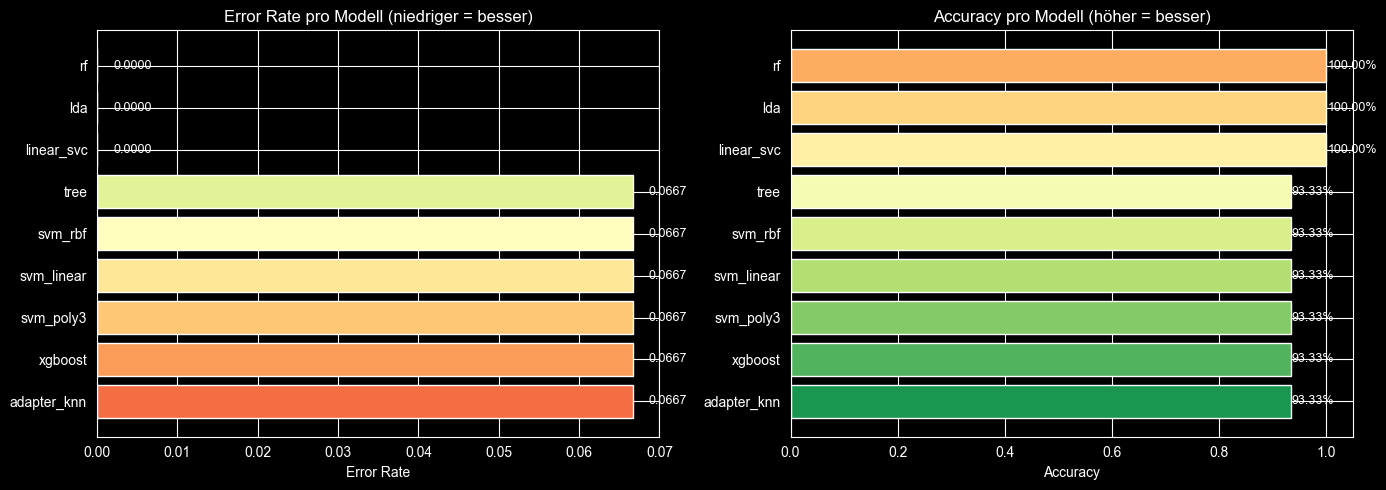

In [10]:
# Balkendiagramm der Error Rates
sorted_results = sorted(trainer.results.items(), key=lambda x: x[1])
modelle = [name for name, _ in sorted_results]
error_rates = [er for _, er in sorted_results]
accuracies = [1 - er for er in error_rates]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Error Rate Balkendiagramm
farben = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(modelle)))
ax1.barh(modelle, error_rates, color=farben)
ax1.set_xlabel('Error Rate')
ax1.set_title('Error Rate pro Modell (niedriger = besser)')
ax1.invert_yaxis()
for i, v in enumerate(error_rates):
    ax1.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# Accuracy Balkendiagramm
farben2 = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(modelle)))
ax2.barh(modelle, accuracies, color=farben2)
ax2.set_xlabel('Accuracy')
ax2.set_title('Accuracy pro Modell (höher = besser)')
ax2.invert_yaxis()
for i, v in enumerate(accuracies):
    ax2.text(v + 0.002, i, f'{v:.2%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Zusammenfassung der Design Patterns

### Strategy Pattern
- **Interface:** `ClassifierStrategy` (ABC) mit `fit()` und `predict()`
- **Konkrete Strategien:** 8 Klassen in `strategies.py` (z.B. `DecisionTreeStrategy`, `RandomForestStrategy`, ...)
- **Kontext:** `Trainer` – kennt nur das Interface, nicht die konkreten Implementierungen
- **Vorteil:** Neue Modelle können hinzugefügt werden, ohne den Trainer zu ändern

### Factory Pattern
- **Factory:** `ClassifierFactory` mit statischem `_strategies`-Dictionary
- **Erzeugung:** `make_classifier(name, **kwargs)` liefert fertige Strategie-Objekte
- **Vorteil:** Client muss keine konkreten Klassen importieren, nur String-Keys verwenden

### Adapter Pattern
- **Adapter:** `SklearnAdapter` adaptiert beliebige sklearn-Modelle an `ClassifierStrategy`
- **Vorteil:** Erweiterung ohne neue Strategy-Klasse, funktioniert mit jedem sklearn-kompatiblen Modell

### Decorator Pattern
- **Decorator:** `@log_method` in `interfaces.py`
- **Zweck:** Loggt automatisch alle `fit()` und `predict()` Aufrufe mit Klassenname und Anzahl der Samples
- **Vorteil:** Logging-Logik ist vom Kern-Algorithmus getrennt (Separation of Concerns)